In [7]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [31]:
df = pd.read_excel("/content/singing_competition_winner_prediction_raw_data.xlsx")

print(df.head())
print(df.shape)

   Season Contestant_ID  Age  Vocal_Score  Pitch_Accuracy  Tone_Score  \
0       1          C001   22         78.8            72.9        84.1   
1       1          C002   35         75.3            81.2        75.2   
2       1          C003   30         78.8            80.5        80.9   
3       1          C004   26         60.1            70.9        76.8   
4       1          C005   23         76.0            82.9        78.9   

   Stage_Presence  Judge_Score  Audience_Votes  Social_Media_Followers  \
0            92.3         77.8           61272                   48730   
1            62.2         79.4           62483                   77866   
2            59.0         78.5           80677                   50928   
3            75.4         73.0           62738                   50976   
4            79.8         81.2           78375                   92010   

   Performance_Count  Eliminated_Week  Performance_Index  Winner  
0                  7                7            

In [9]:
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset statistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Season                  120 non-null    int64  
 1   Contestant_ID           120 non-null    object 
 2   Age                     120 non-null    int64  
 3   Vocal_Score             120 non-null    float64
 4   Pitch_Accuracy          120 non-null    float64
 5   Tone_Score              120 non-null    float64
 6   Stage_Presence          120 non-null    float64
 7   Judge_Score             120 non-null    float64
 8   Audience_Votes          120 non-null    int64  
 9   Social_Media_Followers  120 non-null    int64  
 10  Performance_Count       120 non-null    int64  
 11  Eliminated_Week         120 non-null    int64  
 12  Performance_Index       120 non-null    float64
 13  Winner                  120 non-null    int64  
dtypes: float64(6), int64(7), object(1)
memory 

In [10]:
X = df[
    [
        "Age",
        "Vocal_Score",
        "Pitch_Accuracy",
        "Tone_Score",
        "Stage_Presence",
        "Judge_Score",
        "Audience_Votes",
        "Social_Media_Followers",
        "Performance_Count",
        "Eliminated_Week"
    ]
]

y = df["Winner"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Age  Vocal_Score  Pitch_Accuracy  Tone_Score  Stage_Presence  Judge_Score  \
0   22         78.8            72.9        84.1            92.3         77.8   
1   35         75.3            81.2        75.2            62.2         79.4   
2   30         78.8            80.5        80.9            59.0         78.5   
3   26         60.1            70.9        76.8            75.4         73.0   
4   23         76.0            82.9        78.9            79.8         81.2   

   Audience_Votes  Social_Media_Followers  Performance_Count  Eliminated_Week  
0           61272                   48730                  7                7  
1           62483                   77866                  8                6  
2           80677                   50928                  6               11  
3           62738                   50976                  6                5  
4           78375                   92010                  6                9  

Target:
0    0
1    0
2    0

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (96, 10)
Testing data: (24, 10)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:",
      accuracy_logistic)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 0.9583333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       0.00      0.00      0.00         1

    accuracy                           0.96        24
   macro avg       0.48      0.50      0.49        24
weighted avg       0.92      0.96      0.94        24



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Confusion Matrix:
[[23  0]
 [ 1  0]]


In [15]:
tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:",
      accuracy_tree)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.875

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.91      0.93        23
           1       0.00      0.00      0.00         1

    accuracy                           0.88        24
   macro avg       0.48      0.46      0.47        24
weighted avg       0.91      0.88      0.89        24



In [16]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Confusion Matrix:
[[21  2]
 [ 1  0]]


In [17]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:",
      accuracy_knn)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.9583333333333334

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        23
           1       0.00      0.00      0.00         1

    accuracy                           0.96        24
   macro avg       0.48      0.50      0.49        24
weighted avg       0.92      0.96      0.94        24



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [18]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

Confusion Matrix:
[[23  0]
 [ 1  0]]


In [19]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "KNN"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_tree,
        accuracy_knn
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.958333
1        Decision Tree  0.875000
2                  KNN  0.958333


In [20]:
results["Accuracy (%)"] = results["Accuracy"] * 100

print(results)

                 Model  Accuracy  Accuracy (%)
0  Logistic Regression  0.958333     95.833333
1        Decision Tree  0.875000     87.500000
2                  KNN  0.958333     95.833333


In [21]:
new_contestant = np.array([[
    22,      # Age
    90,      # Vocal Score
    88,      # Pitch Accuracy
    85,      # Tone Score
    92,      # Stage Presence
    89,      # Judge Score
    120000,  # Audience Votes
    150000,  # Social Media Followers
    10,      # Performance Count
    11       # Eliminated Week
]])

new_contestant_scaled = scaler.transform(new_contestant)

logistic_prediction = logistic_model.predict(new_contestant_scaled)
tree_prediction = tree_model.predict(new_contestant)
knn_prediction = knn_model.predict(new_contestant_scaled)

print("Logistic Regression Prediction:",
      "Winner" if logistic_prediction[0] == 1 else "Not Winner")

print("Decision Tree Prediction:",
      "Winner" if tree_prediction[0] == 1 else "Not Winner")

print("KNN Prediction:",
      "Winner" if knn_prediction[0] == 1 else "Not Winner")

Logistic Regression Prediction: Winner
Decision Tree Prediction: Winner
KNN Prediction: Not Winner


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [22]:
probability = logistic_model.predict_proba(
    new_contestant_scaled
)[0][1]

print("Probability of being a winner:",
      round(probability * 100, 2), "%")

Probability of being a winner: 74.49 %


In [23]:
print("=" * 50)
print("SINGING COMPETITION WINNER PREDICTION")
print("=" * 50)

print("Logistic Regression:",
      round(accuracy_logistic * 100, 2), "%")

print("Decision Tree:",
      round(accuracy_tree * 100, 2), "%")

print("KNN:",
      round(accuracy_knn * 100, 2), "%")

print("=" * 50)

SINGING COMPETITION WINNER PREDICTION
Logistic Regression: 95.83 %
Decision Tree: 87.5 %
KNN: 95.83 %


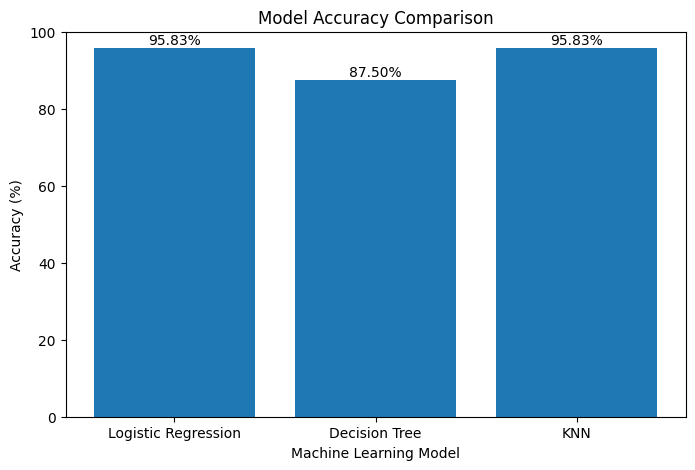

In [24]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Decision Tree",
    "KNN"
]

accuracies = [
    accuracy_logistic * 100,
    accuracy_tree * 100,
    accuracy_knn * 100
]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for i, value in enumerate(accuracies):
    plt.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.show()

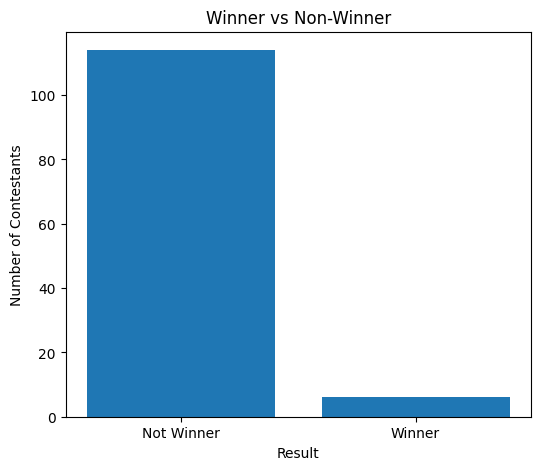

In [25]:
plt.figure(figsize=(6, 5))

winner_counts = df["Winner"].value_counts()

plt.bar(
    ["Not Winner", "Winner"],
    [
        winner_counts.get(0, 0),
        winner_counts.get(1, 0)
    ]
)

plt.title("Winner vs Non-Winner")
plt.xlabel("Result")
plt.ylabel("Number of Contestants")

plt.show()

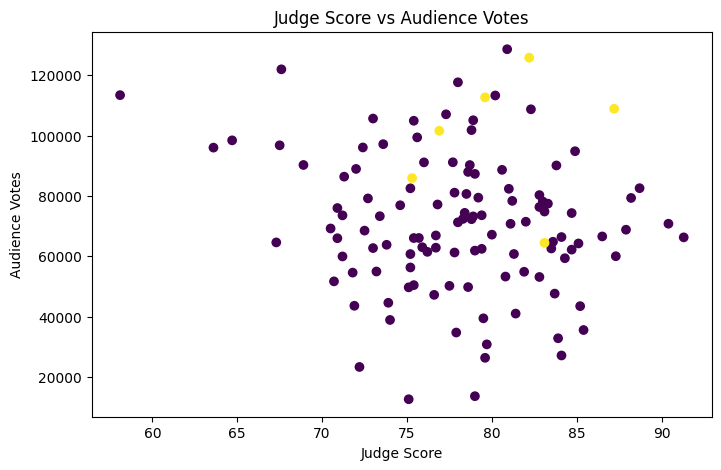

In [26]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Judge_Score"],
    df["Audience_Votes"],
    c=df["Winner"]
)

plt.title("Judge Score vs Audience Votes")
plt.xlabel("Judge Score")
plt.ylabel("Audience Votes")

plt.show()

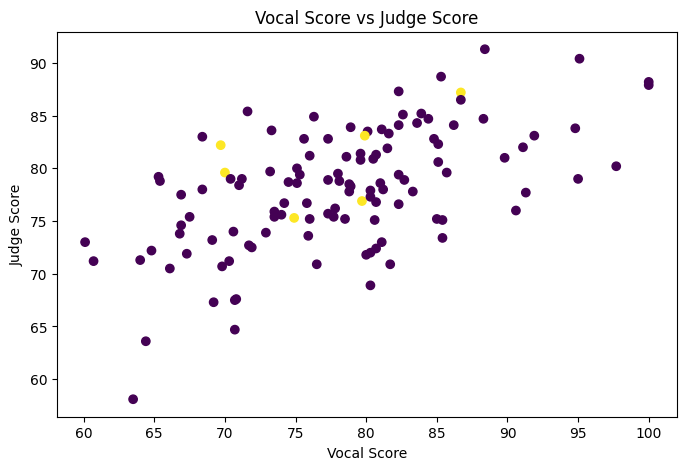

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Vocal_Score"],
    df["Judge_Score"],
    c=df["Winner"]
)

plt.title("Vocal Score vs Judge Score")
plt.xlabel("Vocal Score")
plt.ylabel("Judge Score")

plt.show()

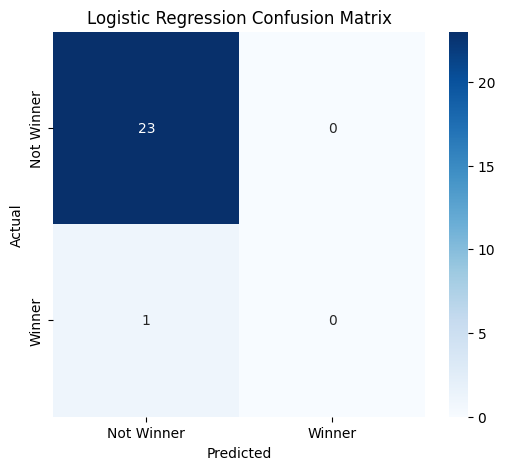

In [28]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Winner", "Winner"],
    yticklabels=["Not Winner", "Winner"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

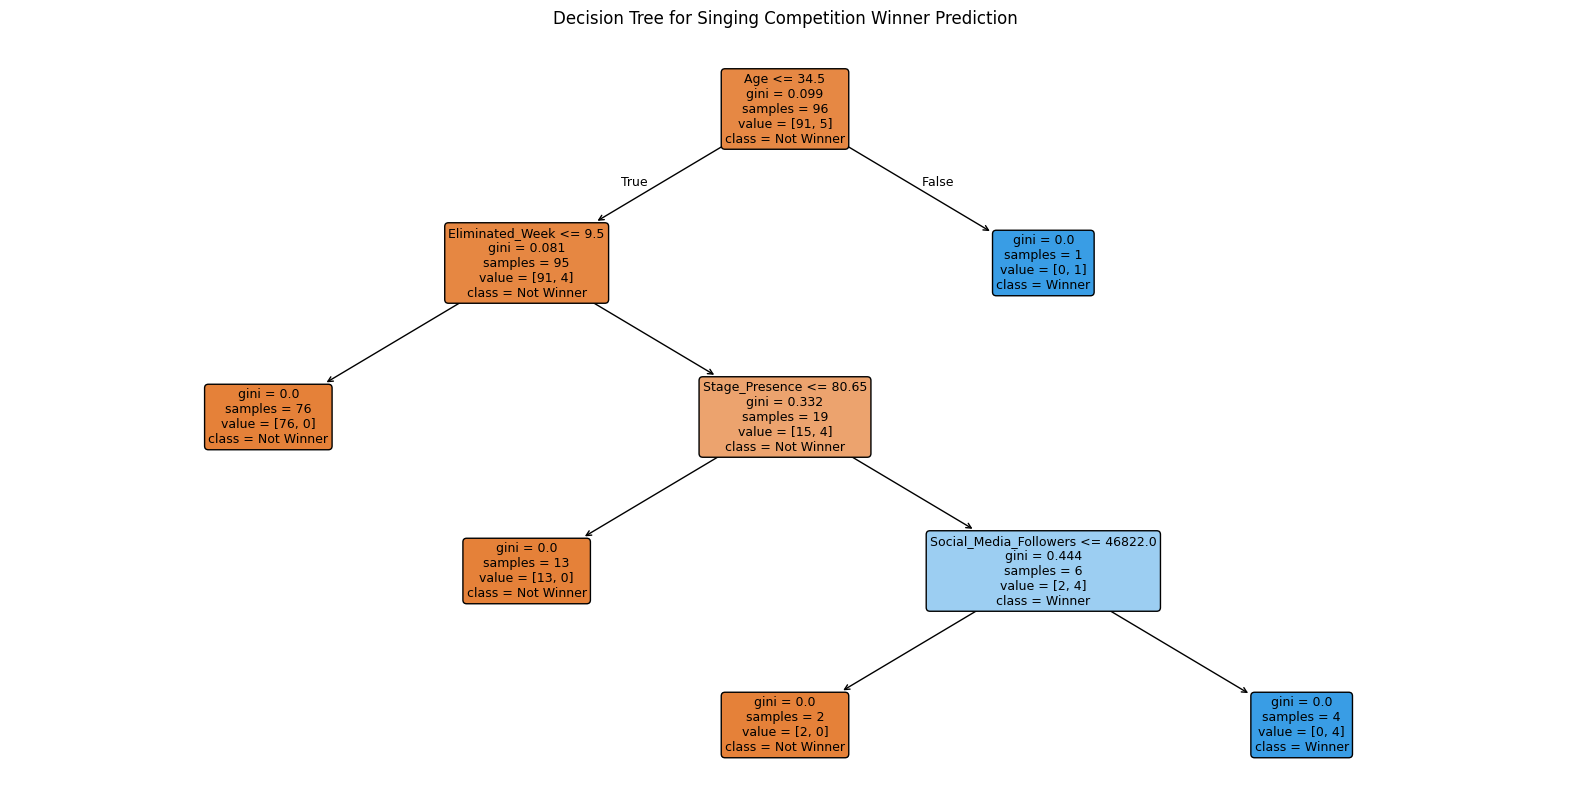

In [29]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Not Winner", "Winner"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree for Singing Competition Winner Prediction")

plt.show()